<a href="https://colab.research.google.com/github/l21141336-glitch/Analisis-y-visualizacion-de-datos/blob/main/C%C3%B3digo_Unidad_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Rows: 120 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): fecha, zona
dbl (1): monto

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 120
Columns: 3
$ fecha <chr> "13/06/2025", "04/03/2025", "23/06/2025", "01/06/2025", "24/01/2…
$ monto <dbl> 4116.28, 6745.45, 18905.69, 11415.16, 6637.99, 6172.68, 12056.41…
$ zona  <chr> "Centro", "Norte", "Norte", "Norte", "Norte", "Occidente", "Cent…


       fecha         monto              zona    
 Length   :120   Min.   : 1583   Length   :120  
 N.unique : 87   1st Qu.: 7006   N.unique :  4  
 N.blank  :  0   Median :12163   N.blank  :  0  
 Min.nchar: 10   Mean   :13133   Min.nchar:  3  
 Max.nchar: 10   3rd Qu.:19168   Max.nchar:  9  
                 Max.   :24621                  

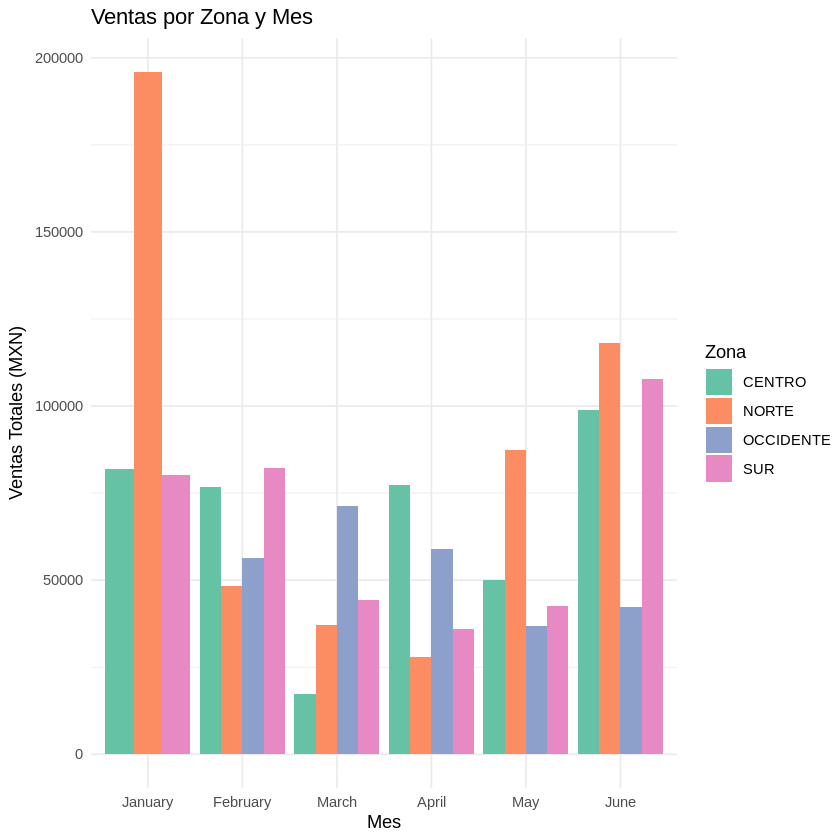

In [3]:
# Instalar paquetes si no los tienes
install.packages("tidyverse")
install.packages("lubridate")

# Cargar librerías
library(tidyverse)
library(lubridate)

# 1. Importar datos
datos <- read_csv("ventas.csv")

# 2. Explorar estructura
glimpse(datos)
summary(datos)

# 3. Limpiar y transformar
datos_limpios <- datos |>
  drop_na(monto) |>
  mutate(
    fecha = dmy(fecha),
    mes = month(fecha, label = TRUE, abbr = FALSE),
    zona = str_to_upper(zona)
  )

# 4. Agregar KPIs
resumen <- datos_limpios |>
  group_by(zona, mes) |>
  summarise(
    total = sum(monto, na.rm = TRUE),
    tickets = n(),
    ticket_prom = mean(monto, na.rm = TRUE),
    .groups = "drop"
  )

# 5. Visualizar
ggplot(resumen, aes(x = mes, y = total, fill = zona)) +
  geom_col(position = "dodge") +
  labs(
    title = "Ventas por Zona y Mes",
    x = "Mes",
    y = "Ventas Totales (MXN)",
    fill = "Zona"
  ) +
  theme_minimal() +
  scale_fill_brewer(palette = "Set2")

Utilidad media esperada: $ 179054 
Probabilidad de pérdida: 2.93 %
IC 95%: [$ -7496 , $ 370234 ]


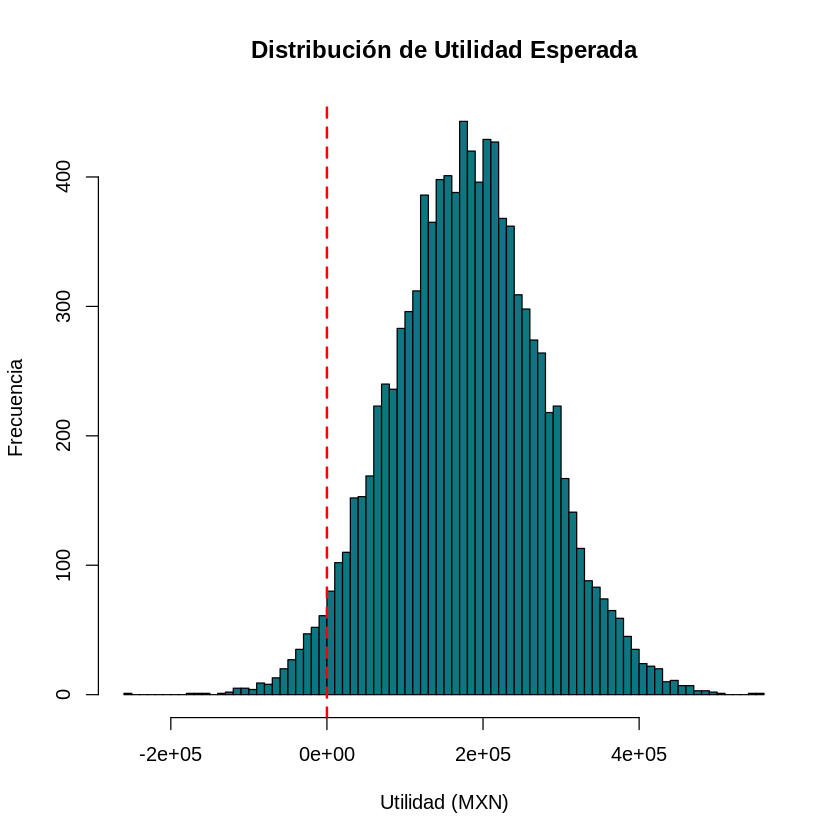

In [2]:
# Simulación Monte Carlo de utilidad esperada

set.seed(42)

# Número de simulaciones
n_sim <- 10000

# Simular ingresos y costos con incertidumbre
ingresos <- rnorm(n_sim, mean = 500000, sd = 80000)
costos <- rnorm(n_sim, mean = 320000, sd = 50000)

# Calcular utilidad
utilidad <- ingresos - costos

# Resultados
cat("Utilidad media esperada: $", round(mean(utilidad), 0), "\n")
cat("Probabilidad de pérdida:", round(mean(utilidad < 0) * 100, 2), "%\n")
cat(
  "IC 95%: [$", round(quantile(utilidad, 0.025), 0),
  ", $", round(quantile(utilidad, 0.975), 0), "]\n"
)

# Histograma de resultados
hist(
  utilidad,
  breaks = 60,
  col = "#0D7680",
  main = "Distribución de Utilidad Esperada",
  xlab = "Utilidad (MXN)",
  ylab = "Frecuencia"
)

# Línea de referencia en utilidad cero
abline(v = 0, col = "red", lwd = 2, lty = 2)